# Module 4 — Customization

Plots are now possible. This module is about making them readable, polished, and publication-ready.

Coming from ggplot2, this corresponds roughly to knowledge around `theme()`, `scale_*()`, `labs()`, and `annotate()`, but matplotlib splits those ideas across many small `ax.*` methods rather than one composable theme system.

The mental model:

```text
┌──────────────────────────────────────────────────────┐
│ An Axes is a collection of customizable parts.       │
│ You modify each part by calling a method on `ax`.    │
└──────────────────────────────────────────────────────┘

             ┌──── title ────┐
             │   My Plot     │      ax.set_title()
             │               │
spines ───→  │   ▲           │  ←── spines: ax.spines[...]
(the box)    │   │ • •       │
             │   │ • • •     │
             │   │   •       │  ←── annotations / text:
             │   └─────►     │      ax.annotate(), ax.text()
             │   ↑     ↑     │
             │ ticks   │     │      ax.set_xticks()
             │         │     │
             │ x-label │     │      ax.set_xlabel()
             └───────────────┘

 y-label: ax.set_ylabel()
```

The customizations below follow roughly the order they are usually added to a plot.

## 1. Titles, labels, and basic text

The basic text methods are used constantly:

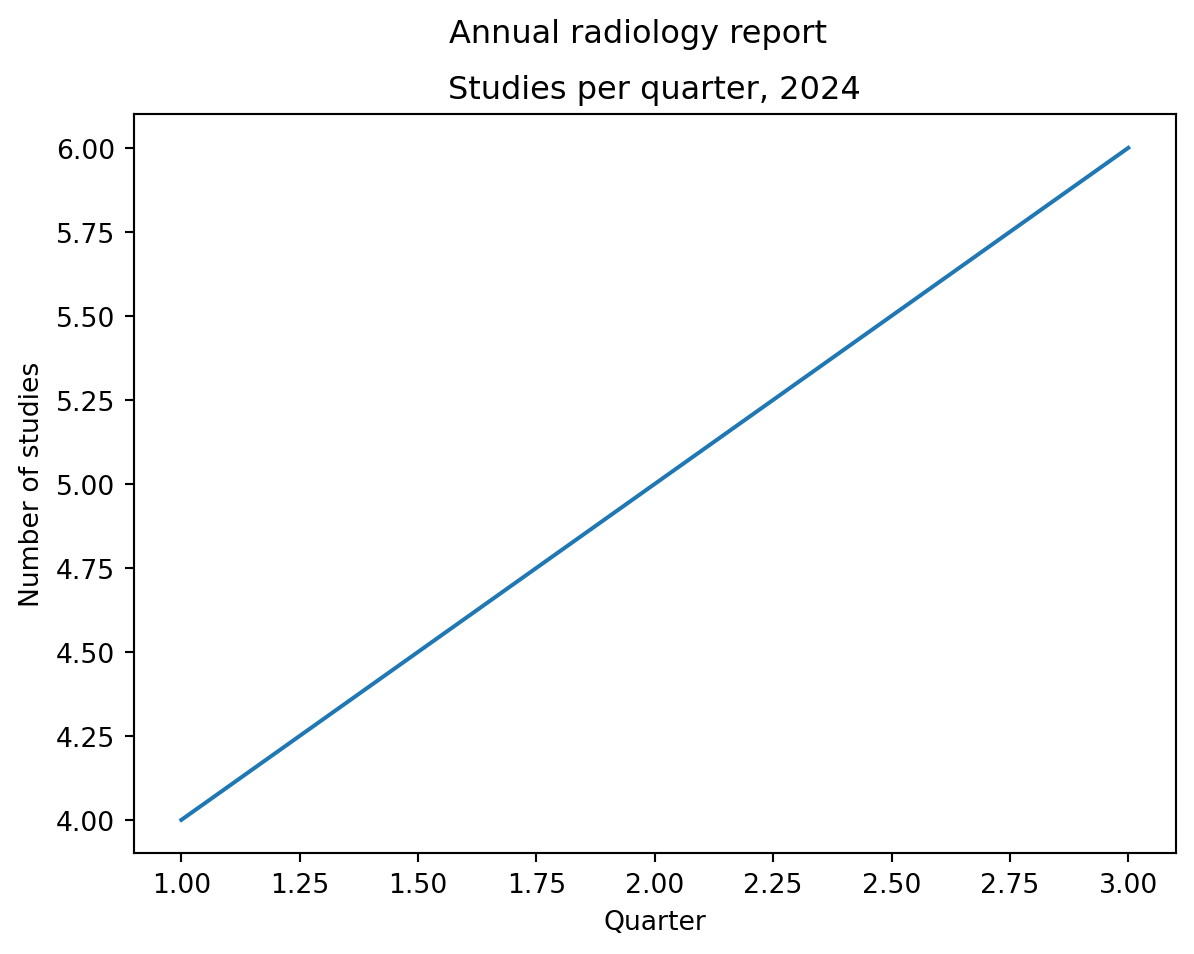

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])

ax.set_title("Studies per quarter, 2024")  # title above this axes
ax.set_xlabel("Quarter")                   # x-axis label
ax.set_ylabel("Number of studies")         # y-axis label

fig.suptitle("Annual radiology report")    # title above the whole figure
plt.show()

The distinction matters:

- `ax.set_title()` titles one panel.
- `fig.suptitle()` titles the whole figure.

This becomes especially important with multiple subplots.

Most text methods accept styling keywords:

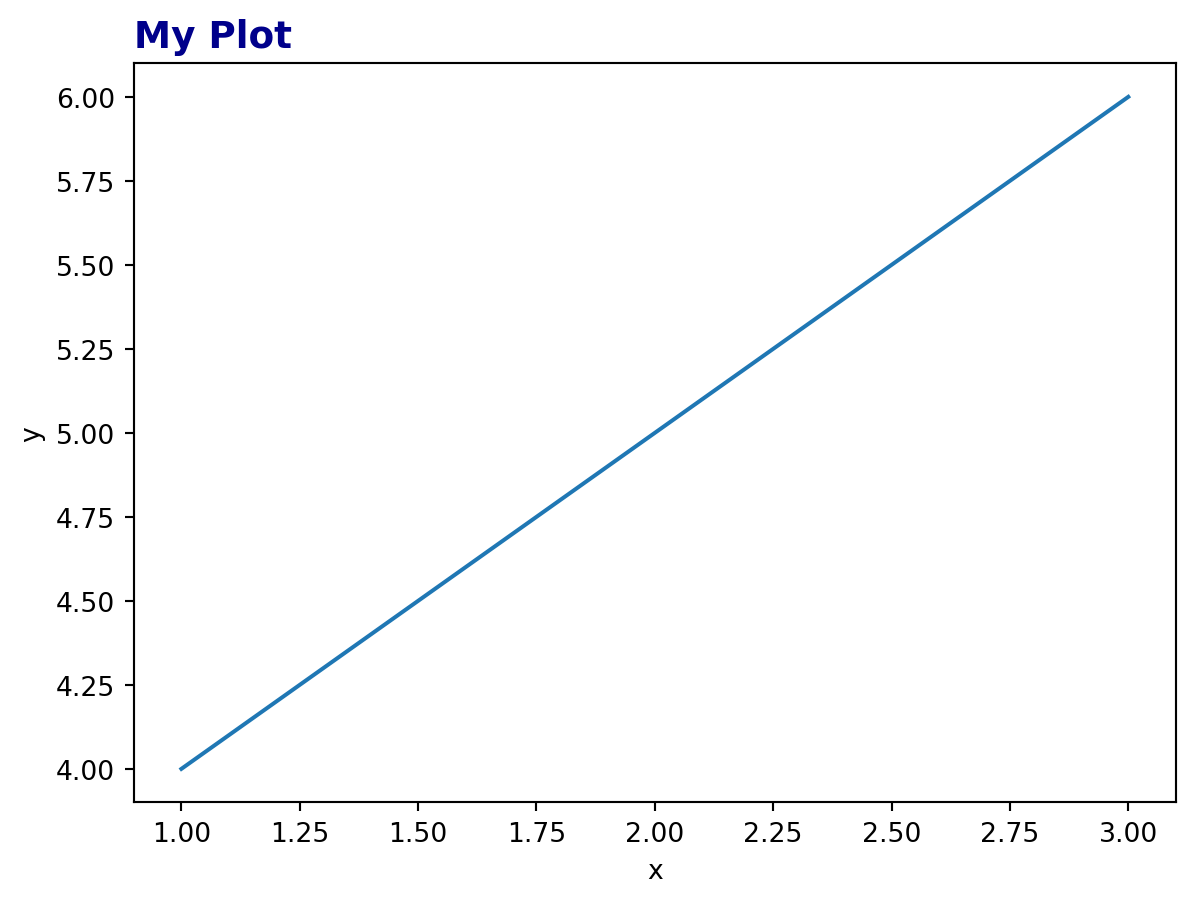

In [2]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])

ax.set_title(
    "My Plot",
    fontsize=14,
    fontweight="bold",
    color="darkblue",
    loc="left",  # "left", "center" (default), or "right"
)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

## 2. Axis limits and scales

Axis limits define the visible data window. Axis scales define how data values map to visual position.

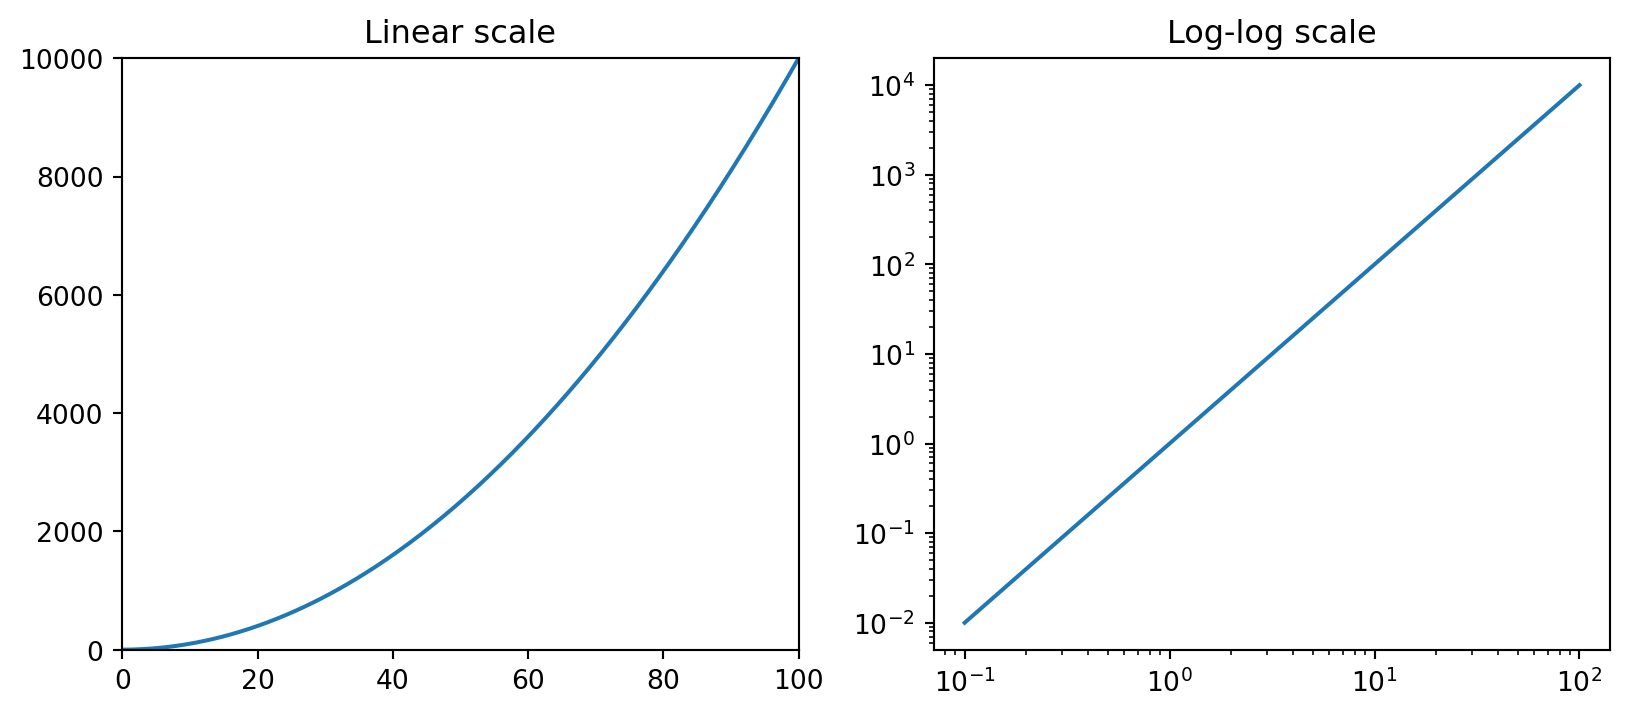

In [3]:
import numpy as np

x = np.linspace(0.1, 100, 300)
y = x ** 2

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x, y)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 10_000)
axes[0].set_title("Linear scale")

axes[1].plot(x, y)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Log-log scale")

plt.show()

Common methods:

```python
ax.set_xlim(0, 100)       # set x range
ax.set_ylim(-1, 1)        # set y range
ax.set_xlim(left=0)       # set only one end, leave the other automatic

ax.set_xscale("log")     # log scale on x
ax.set_yscale("log")     # log scale on y
ax.set_yscale("symlog")  # log-like scale that handles zero/negative values
```

### ggplot2 mapping

| ggplot2 | matplotlib |
|---|---|
| `+ xlim(0, 100)` | `ax.set_xlim(0, 100)` |
| `+ scale_y_log10()` | `ax.set_yscale("log")` |
| `+ coord_cartesian(...)` | `ax.set_xlim()` / `ax.set_ylim()` without dropping data |

Subtle gotcha: `set_xlim()` and `set_ylim()` do **not** filter data. They change only the visible window. The data remain present in the plot object. This is closer to ggplot2's `coord_cartesian()` than to data filtering.

## 3. Ticks: the fiddly part

Ticks are where matplotlib customization often becomes verbose.

The basic split:

```text
┌─────────────────────────────────────────────────────────┐
│ Tick locations → where the ticks appear                │
│ Tick labels    → what text shows at each tick           │
│ Tick style     → font, rotation, size, color            │
└─────────────────────────────────────────────────────────┘
```

### Setting tick positions and labels

For categorical plots, it is common to set numeric positions first, then map those positions to labels.

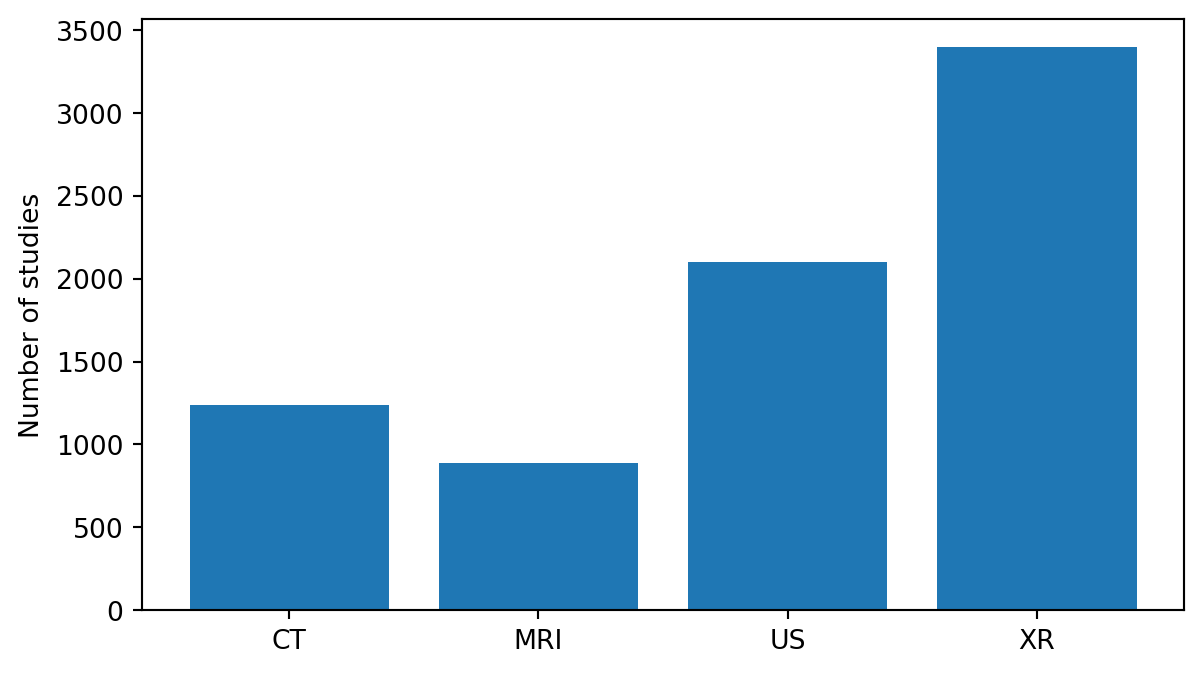

In [4]:
modalities = ["CT", "MRI", "US", "XR"]
counts = [1240, 890, 2100, 3400]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(modalities)), counts)

ax.set_xticks(range(len(modalities)))  # tick positions: [0, 1, 2, 3]
ax.set_xticklabels(modalities)         # labels at those positions
ax.set_ylabel("Number of studies")
plt.show()

Modern matplotlib (≥3.5) can set positions and labels in one call:

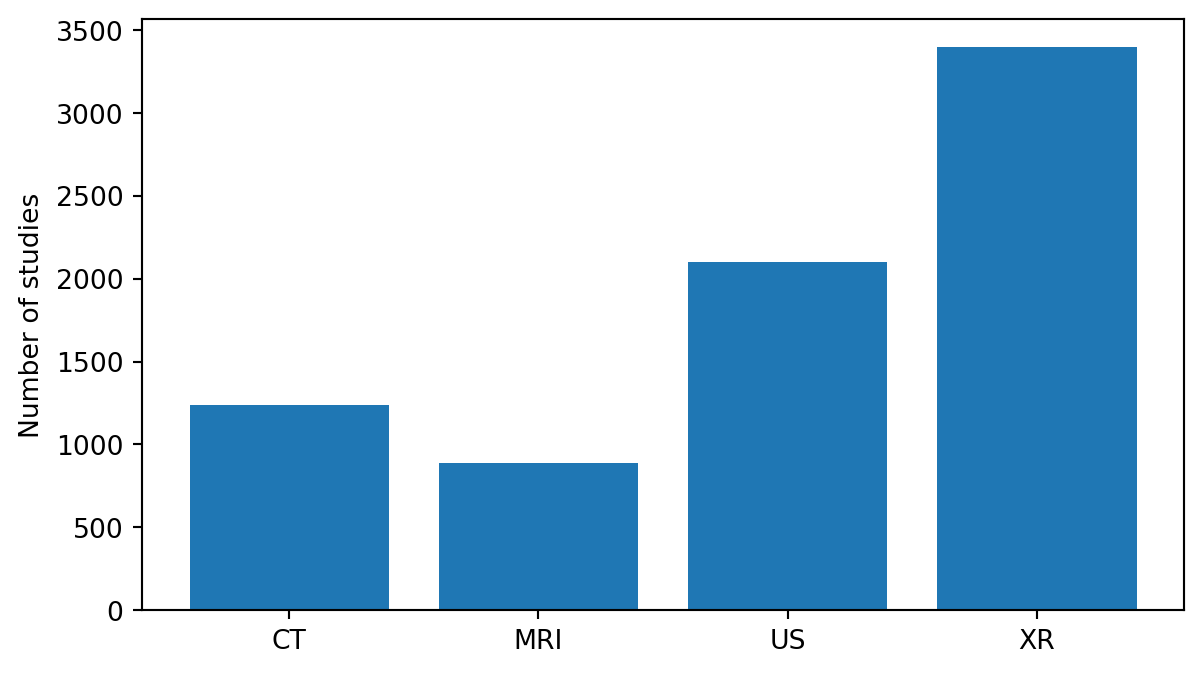

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(modalities)), counts)

ax.set_xticks(range(len(modalities)), labels=modalities)
ax.set_ylabel("Number of studies")
plt.show()

### Rotating tick labels

Rotating tick labels is very common when category names are long and overlap.

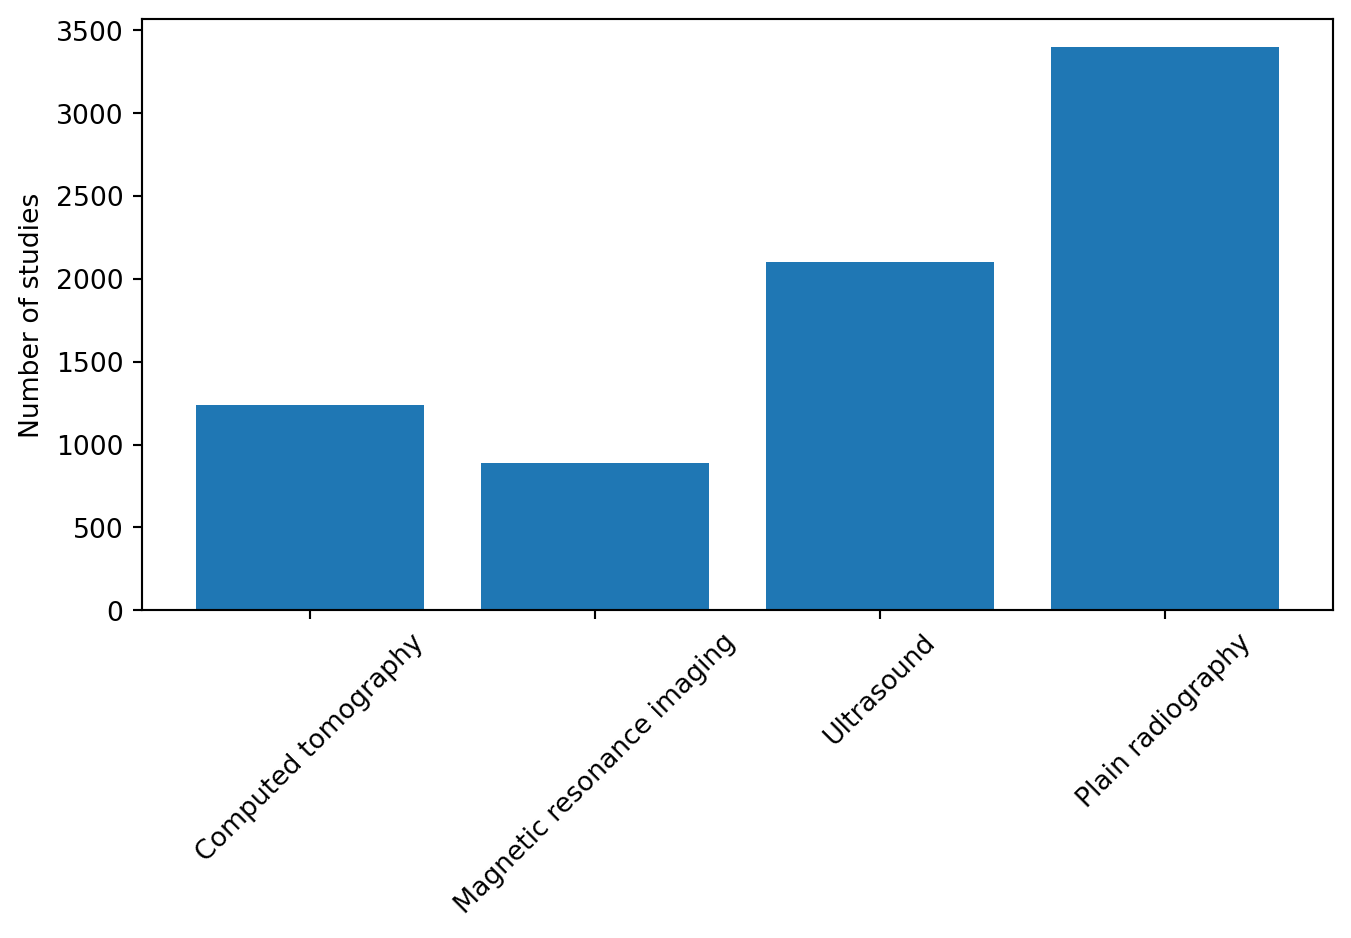

In [6]:
modalities_long = [
    "Computed tomography",
    "Magnetic resonance imaging",
    "Ultrasound",
    "Plain radiography",
]
counts = [1240, 890, 2100, 3400]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(modalities_long)), counts)
ax.set_xticks(range(len(modalities_long)), labels=modalities_long)
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Number of studies")
plt.show()

A more controlled version uses `plt.setp()` to set properties on the tick label `Text` objects:

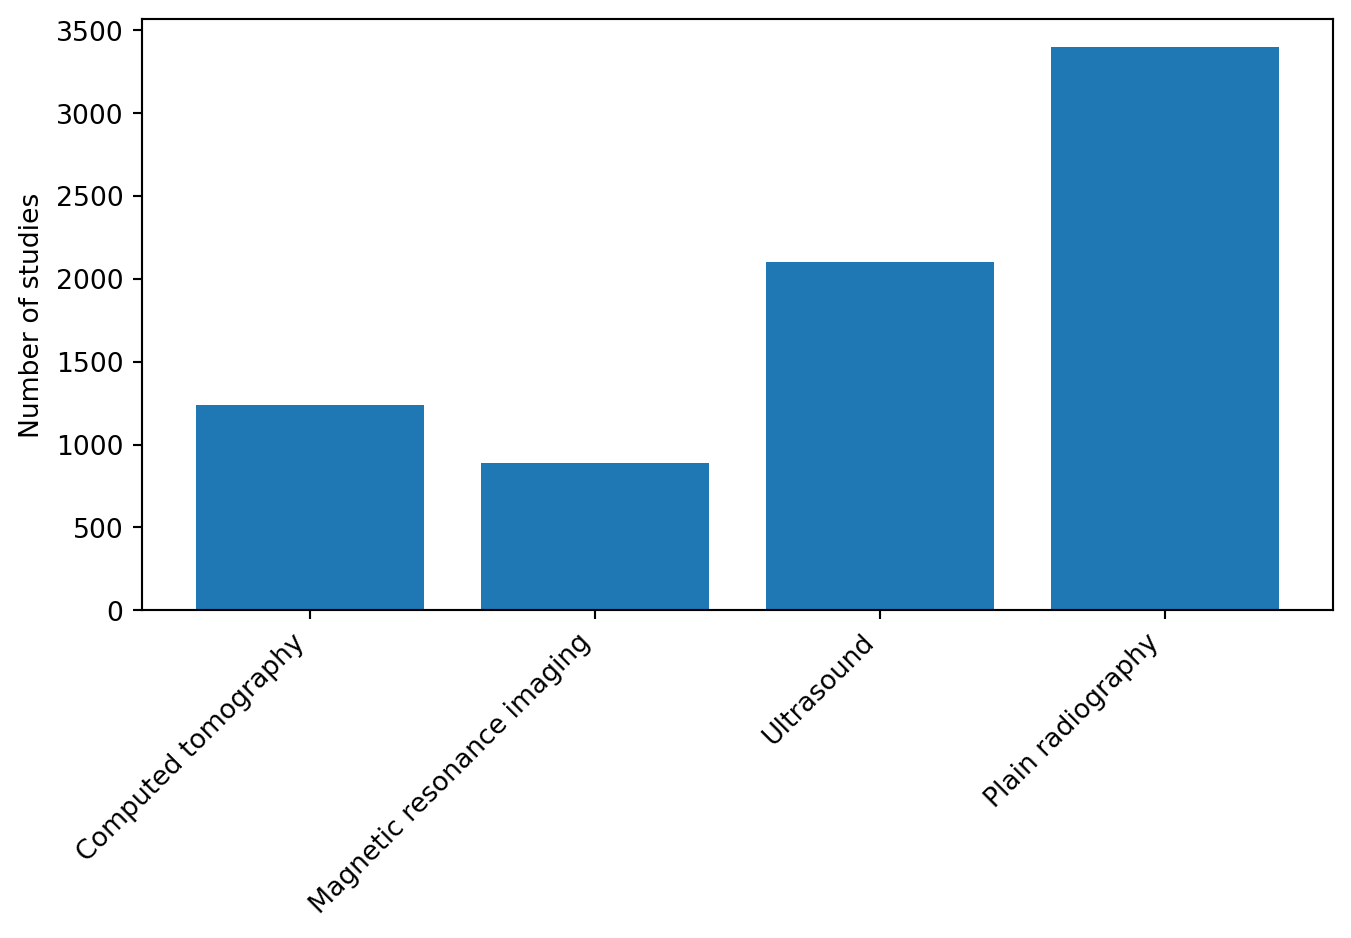

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(modalities_long)), counts)
ax.set_xticks(range(len(modalities_long)), labels=modalities_long)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylabel("Number of studies")
plt.show()

The `ha="right"` argument sets horizontal alignment. It makes rotated labels align cleanly with their tick marks instead of floating awkwardly.

### Removing or hiding ticks

Sometimes ticks or labels add clutter. Common patterns:

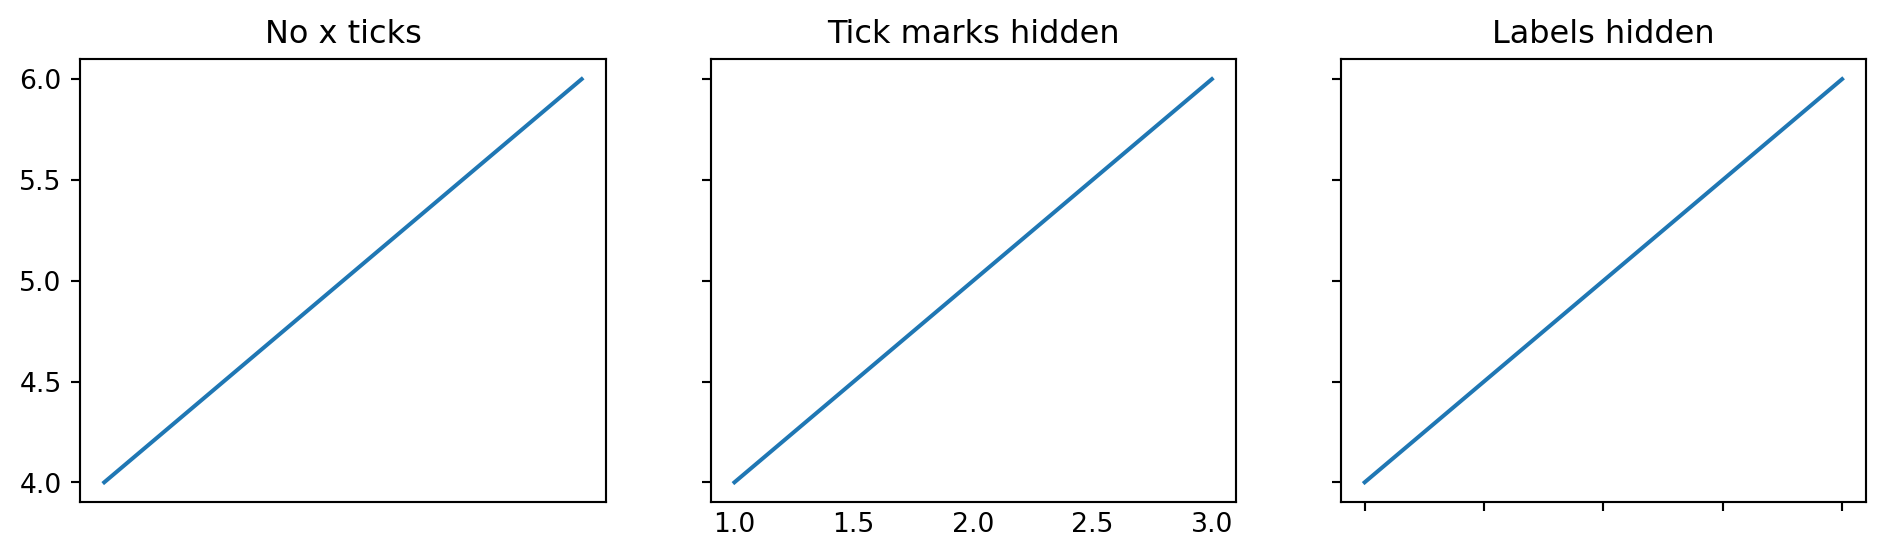

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for ax in axes:
    ax.plot([1, 2, 3], [4, 5, 6])

axes[0].set_title("No x ticks")
axes[0].set_xticks([])

axes[1].set_title("Tick marks hidden")
axes[1].tick_params(axis="x", which="both", length=0)

axes[2].set_title("Labels hidden")
axes[2].tick_params(labelbottom=False)

plt.show()

Equivalent snippets:

```python
ax.set_xticks([])                                  # no ticks at all
ax.tick_params(axis="x", which="both", length=0)  # tick marks invisible but labels stay
ax.tick_params(labelbottom=False)                  # hide x tick labels
```

### Formatting numeric ticks

For thousands separators, percentages, and scientific notation, use formatters from `matplotlib.ticker`.

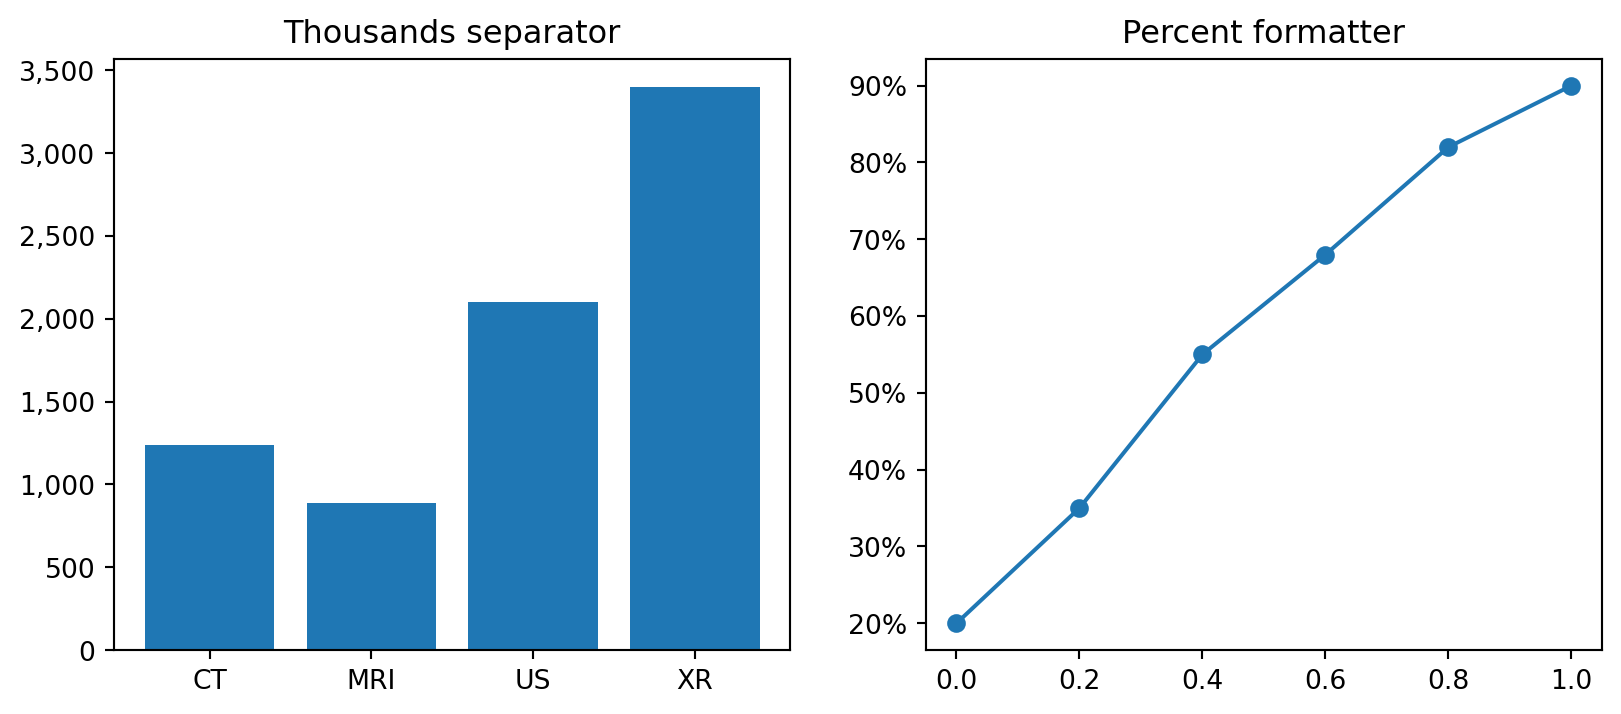

In [9]:
from matplotlib.ticker import FuncFormatter, PercentFormatter

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

modalities = ["CT", "MRI", "US", "XR"]
counts = [1240, 890, 2100, 3400]
axes[0].bar(modalities, counts)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].set_title("Thousands separator")

thresholds = np.linspace(0, 1, 6)
performance = [0.2, 0.35, 0.55, 0.68, 0.82, 0.9]
axes[1].plot(thresholds, performance, marker="o")
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[1].set_title("Percent formatter")

plt.show()

Useful snippets:

```python
from matplotlib.ticker import FuncFormatter, PercentFormatter

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
```

This is not something to memorize immediately. It is enough to remember that tick formatters exist, because confusing numeric tick labels are a frequent source of frustration.

## 4. Legends

Legends are created from `label=` values in drawing calls. Calling `ax.legend()` then renders the legend.

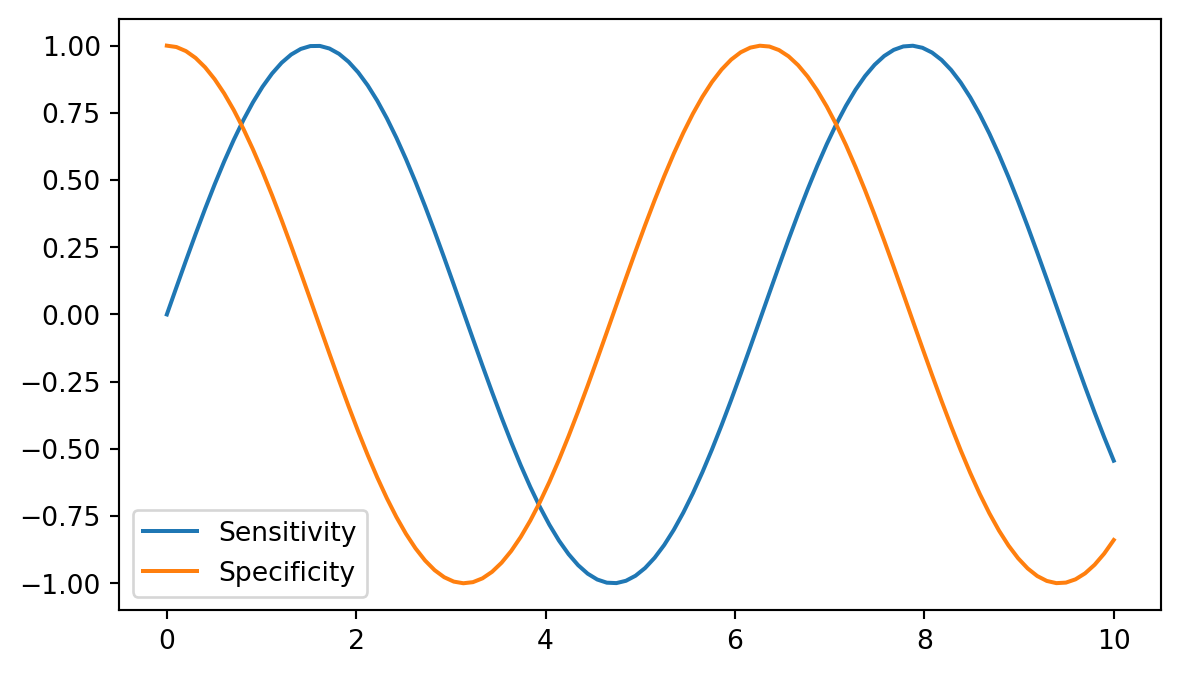

In [10]:
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y1, label="Sensitivity")
ax.plot(x, y2, label="Specificity")
ax.legend()
plt.show()

Useful legend options:

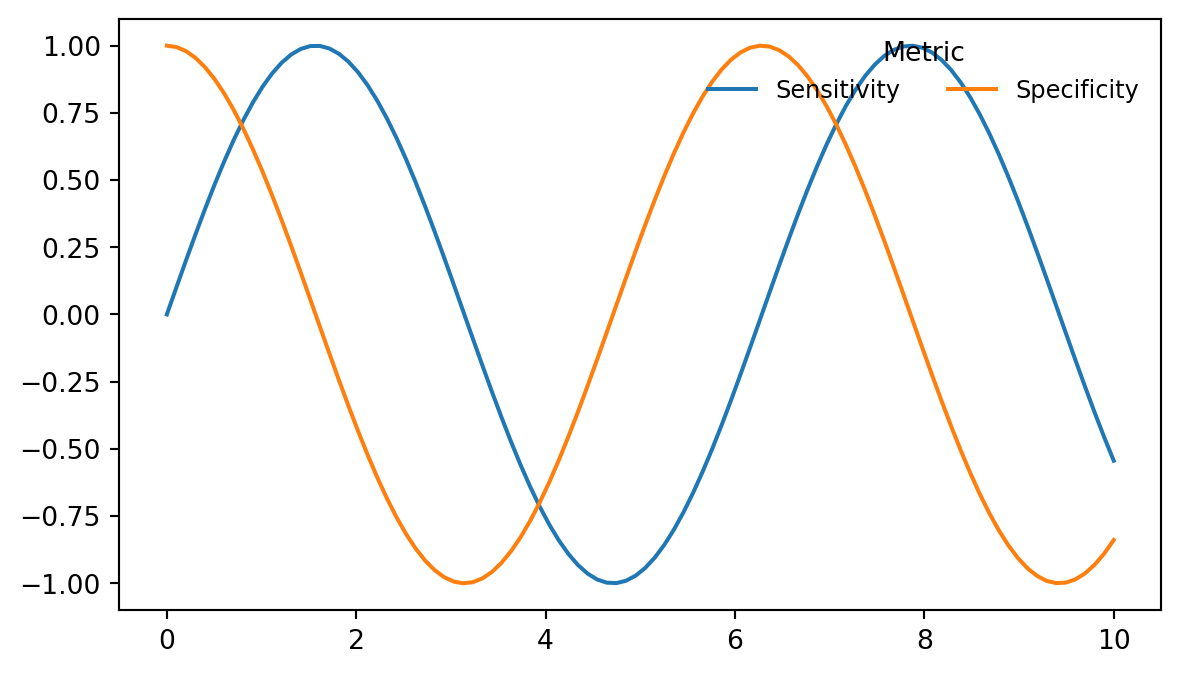

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y1, label="Sensitivity")
ax.plot(x, y2, label="Specificity")
ax.legend(
    loc="upper right",  # or "best", "lower left", etc.
    title="Metric",
    frameon=False,
    ncol=2,
    fontsize=9,
)
plt.show()

`loc="best"` tries to find a location with the least data overlap. It is usually acceptable, but sometimes wrong.

For full control, combine `loc` with `bbox_to_anchor`:

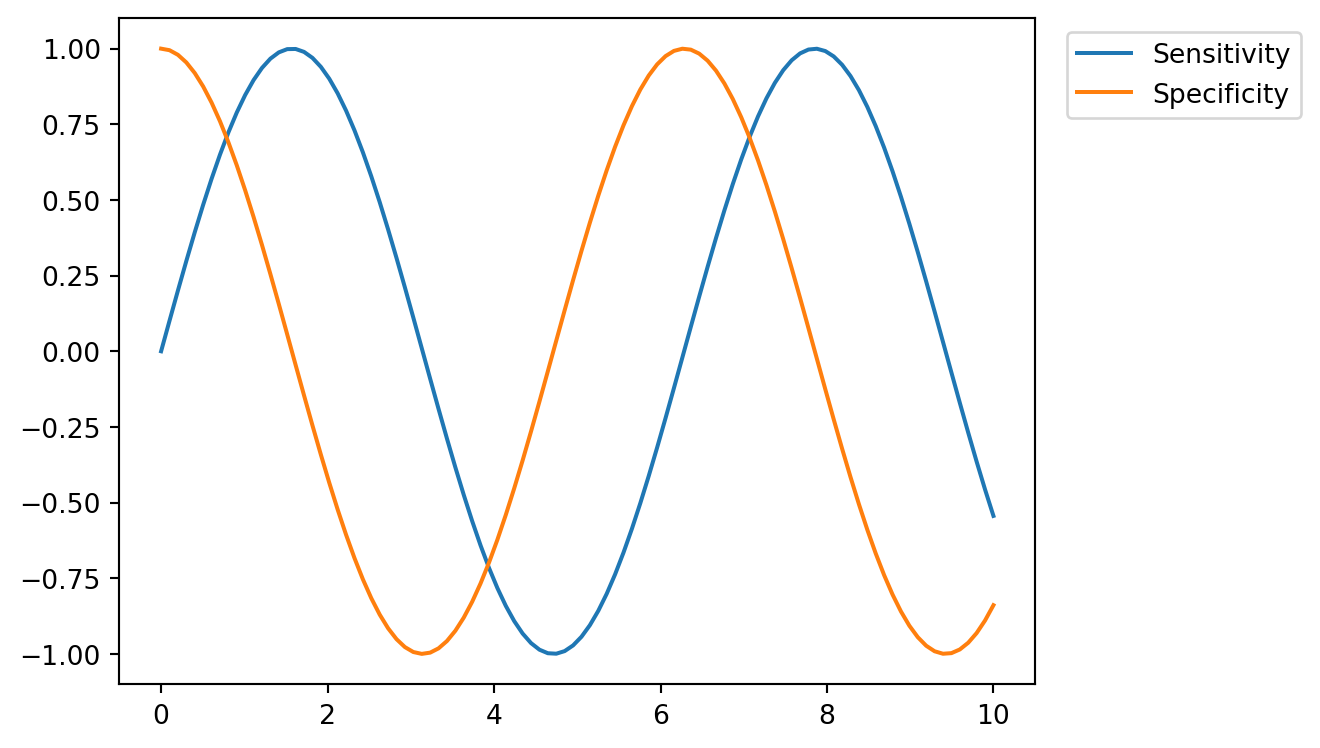

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y1, label="Sensitivity")
ax.plot(x, y2, label="Specificity")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
plt.show()

Legend placement options:

```text
 upper left        upper center        upper right
 ┌──────────────────────────────────────────────┐
 │                                              │
 │                                              │
center left          center           center right
 │                                              │
 │                                              │
 └──────────────────────────────────────────────┘
 lower left        lower center        lower right
```

## 5. Annotations: text and arrows

The two main annotation tools are `ax.text()` and `ax.annotate()`.

### `ax.text(x, y, "...")`: plain text at a coordinate

Coordinates are in data space by default.

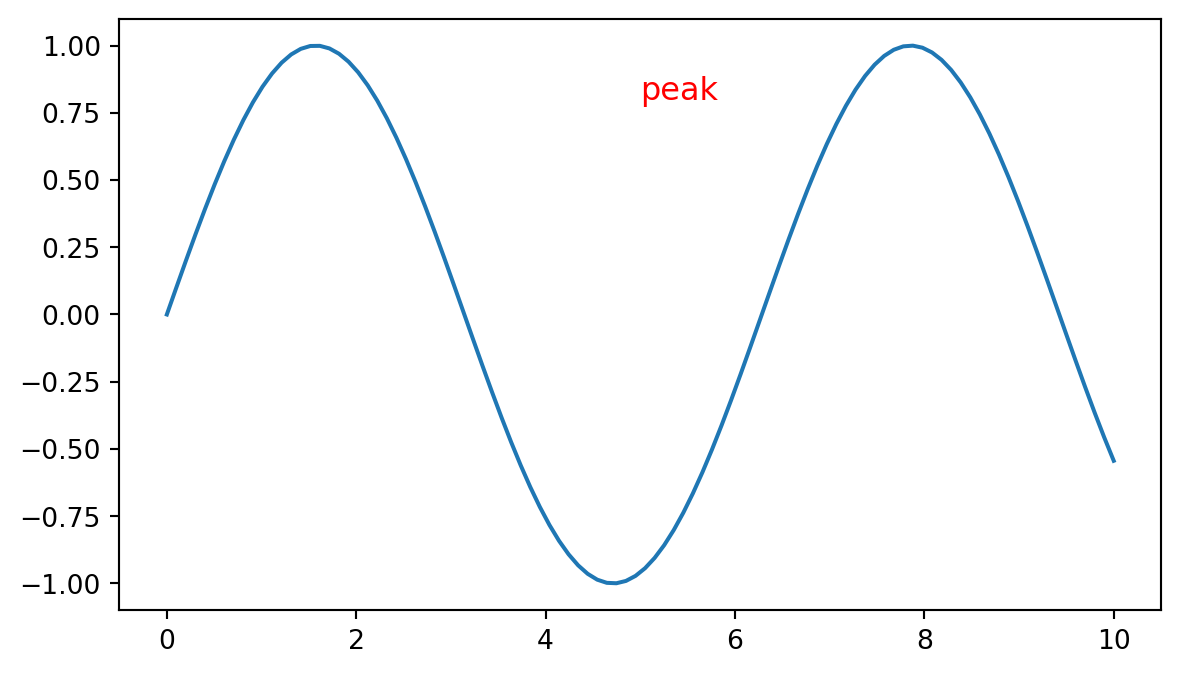

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.sin(x))
ax.text(5, 0.8, "peak", fontsize=12, color="red")
plt.show()

For positioning relative to the axes, such as the top-left corner, use `transform=ax.transAxes`:

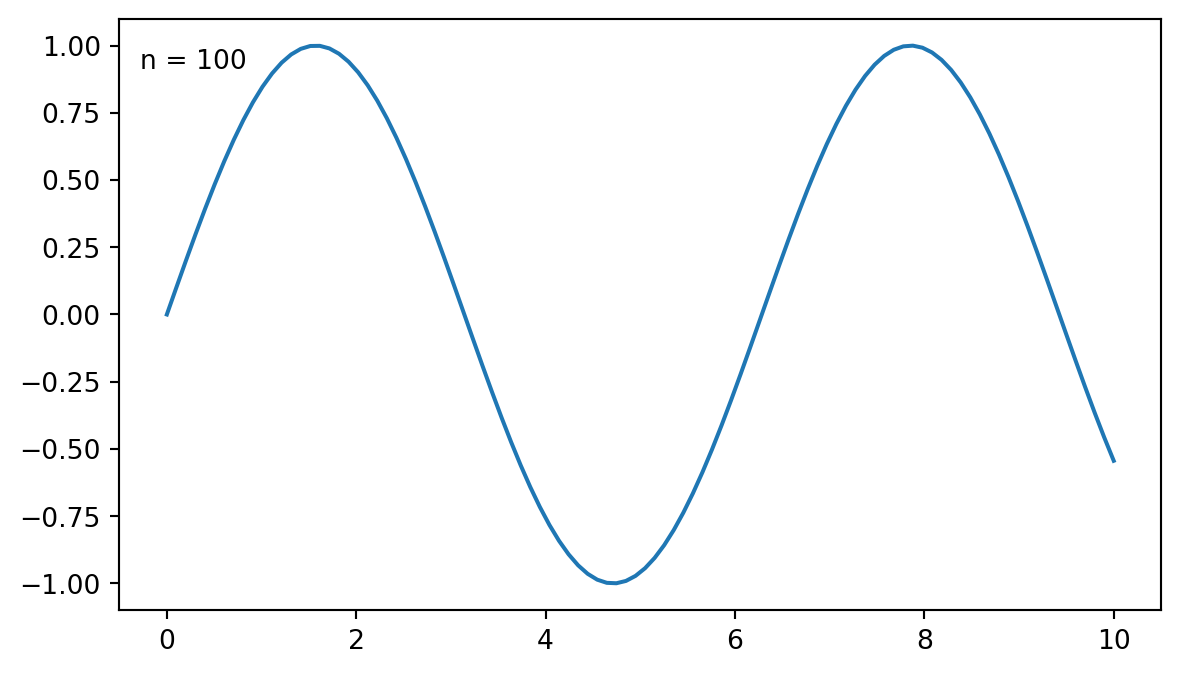

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.sin(x))
ax.text(
    0.02,
    0.95,
    "n = 100",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
)
plt.show()

Coordinate systems:

```text
Data coords (default): same units as your data
  (5, 0.8) = x=5, y=0.8

Axes coords (transform=ax.transAxes):
  (0, 0)     = bottom-left of plot
  (1, 1)     = top-right of plot
  (0.5, 0.5) = center of plot
```

### `ax.annotate()`: text plus arrow

`ax.annotate()` is the classic tool for labeling a point.

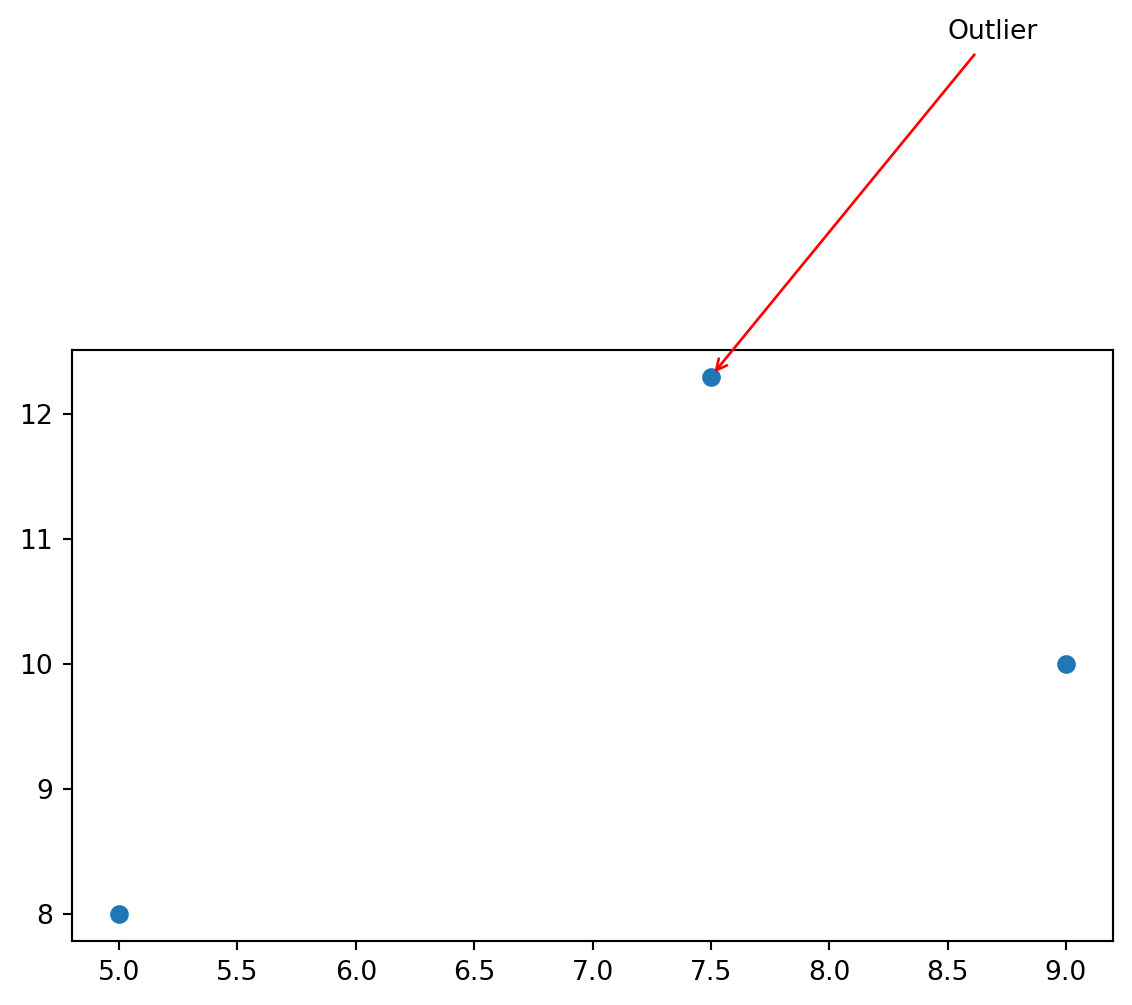

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter([5, 7.5, 9], [8, 12.3, 10])

ax.annotate(
    "Outlier",
    xy=(7.5, 12.3),     # point being annotated
    xytext=(8.5, 15),   # text position
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10,
)
plt.show()

`xy` is the point being annotated. `xytext` is where the text label sits. The arrow is drawn between them.

A radiology-flavored example:

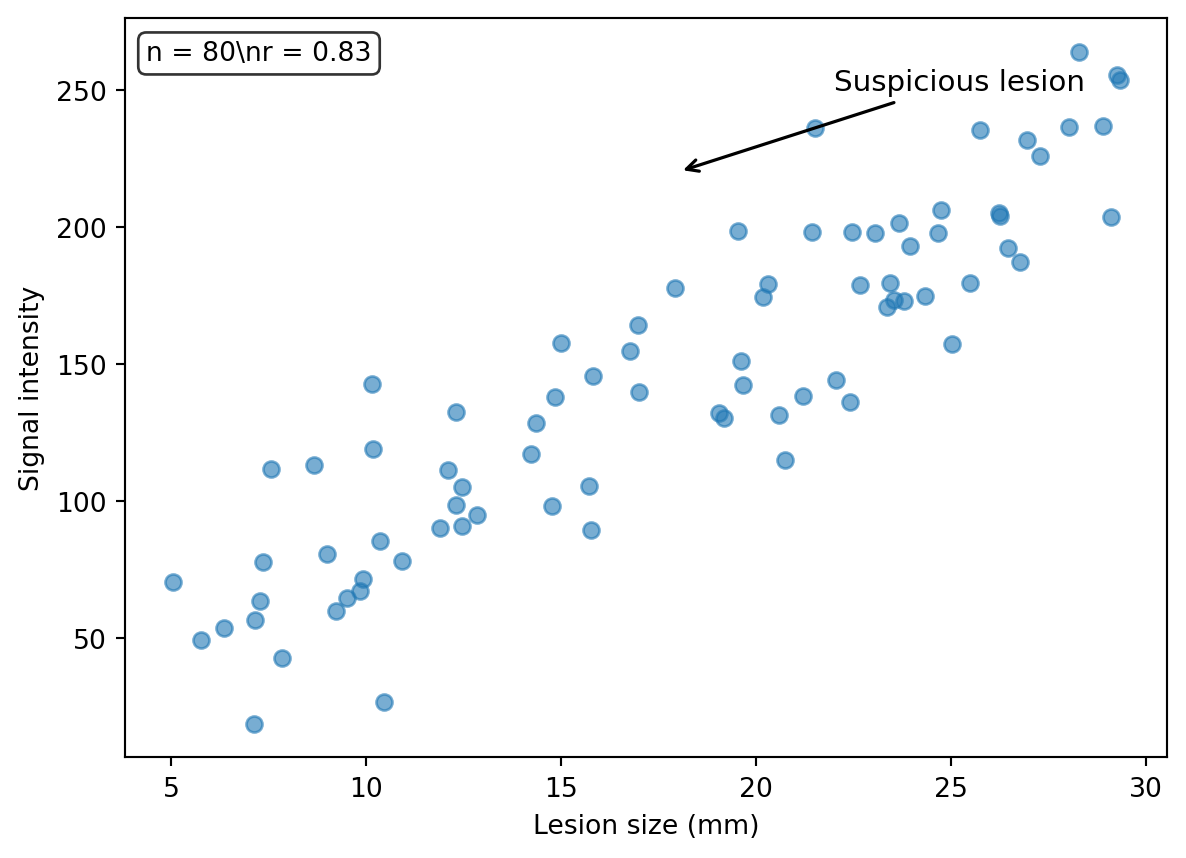

In [16]:
rng = np.random.default_rng(3)
sizes = rng.uniform(5, 30, 80)
signal_intensities = 8 * sizes + rng.normal(0, 25, 80)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sizes, signal_intensities, alpha=0.6)

ax.annotate(
    "Suspicious lesion",
    xy=(18, 220),
    xytext=(22, 250),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=11,
)

# Stats box in the corner
ax.text(
    0.02,
    0.97,
    f"n = {len(sizes)}\\nr = 0.83",
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

ax.set_xlabel("Lesion size (mm)")
ax.set_ylabel("Signal intensity")
plt.show()

The `bbox=dict(...)` argument adds a rounded box around the text, which is common in publication figures.

## 6. Spines: the four lines around the plot

The box around a plot is made of four spines: top, right, bottom, and left. Many modern publication styles hide the top and right spines.

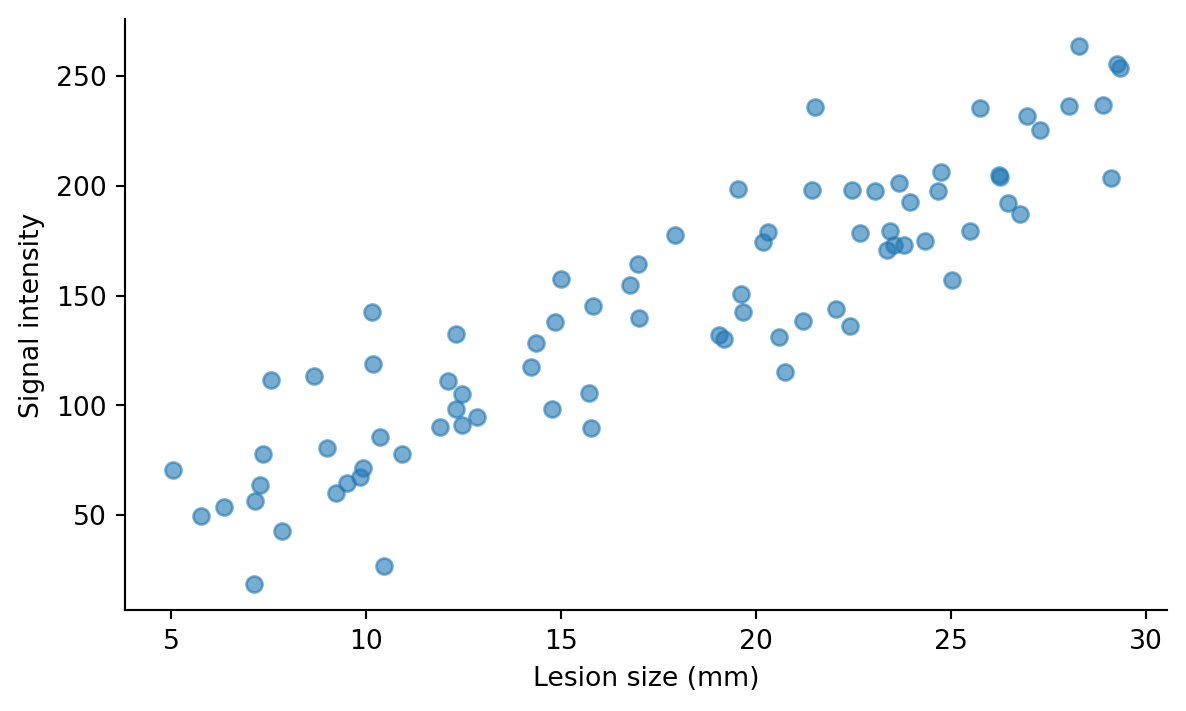

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(sizes, signal_intensities, alpha=0.6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Make remaining spines thinner
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

ax.set_xlabel("Lesion size (mm)")
ax.set_ylabel("Signal intensity")
plt.show()

```text
Default                         Cleaner publication style
─────────                       ──────────────────────────
┌─────────────┐
│             │                         • •
│   • •       │                         • • •
│   • • •     │                         •
│             │
└─────────────┘                 └─────────────
```

This single tweak often makes plots look noticeably more polished.

## 7. Grids

Matplotlib has no grid by default. A light grid can help readability without overwhelming the data.

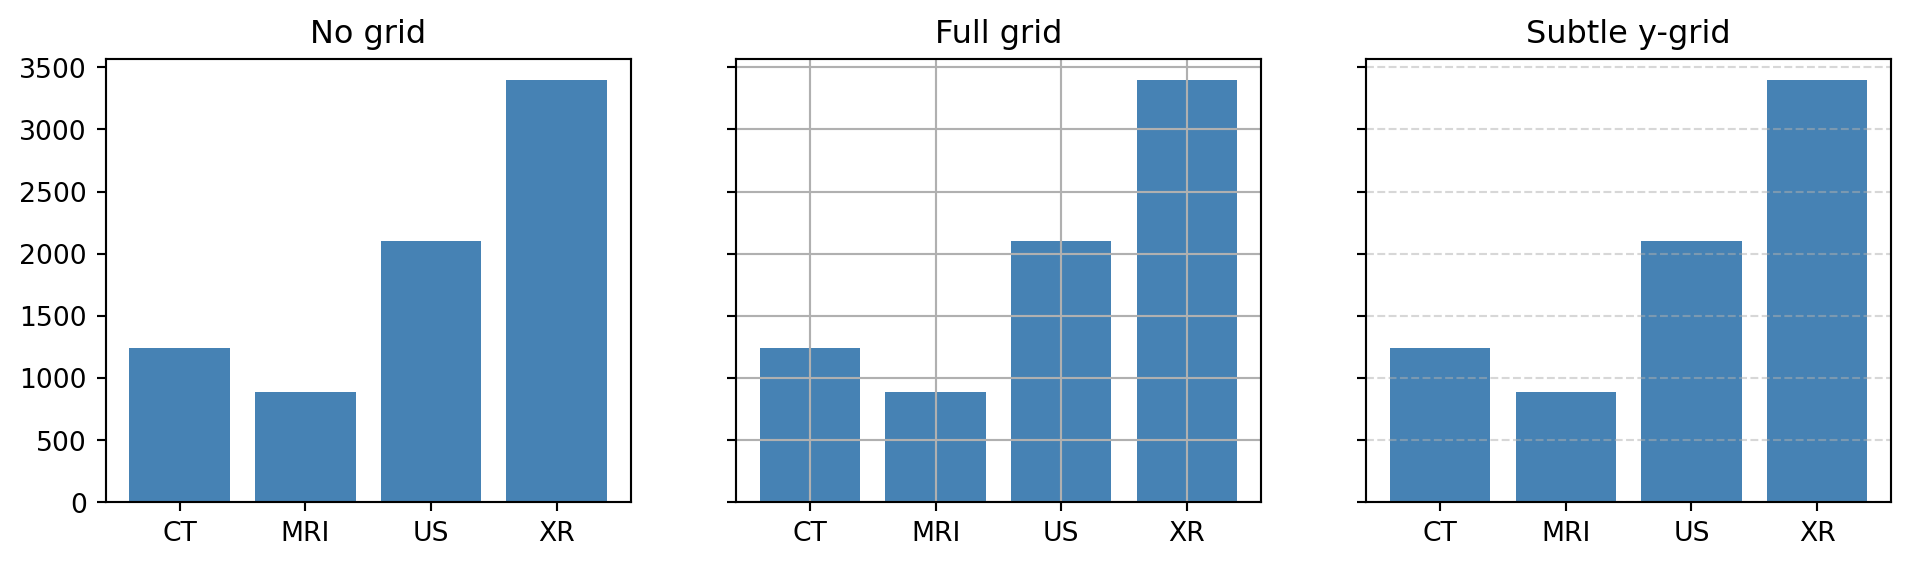

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for ax in axes:
    ax.bar(modalities, counts, color="steelblue")

axes[0].set_title("No grid")

axes[1].set_title("Full grid")
axes[1].grid(True)

axes[2].set_title("Subtle y-grid")
axes[2].grid(True, axis="y", linestyle="--", alpha=0.5)

plt.show()

Useful snippets:

```python
ax.grid(True)                              # grid on
ax.grid(True, axis="y")                   # only horizontal grid lines
ax.grid(True, linestyle="--", alpha=0.5)  # subtle dashed grid
```

A sensible middle ground is a light dashed grid on the y-axis only, especially for bar charts.

## 8. Putting it all together: a polished example

This example uses most of the customization tools from the module.

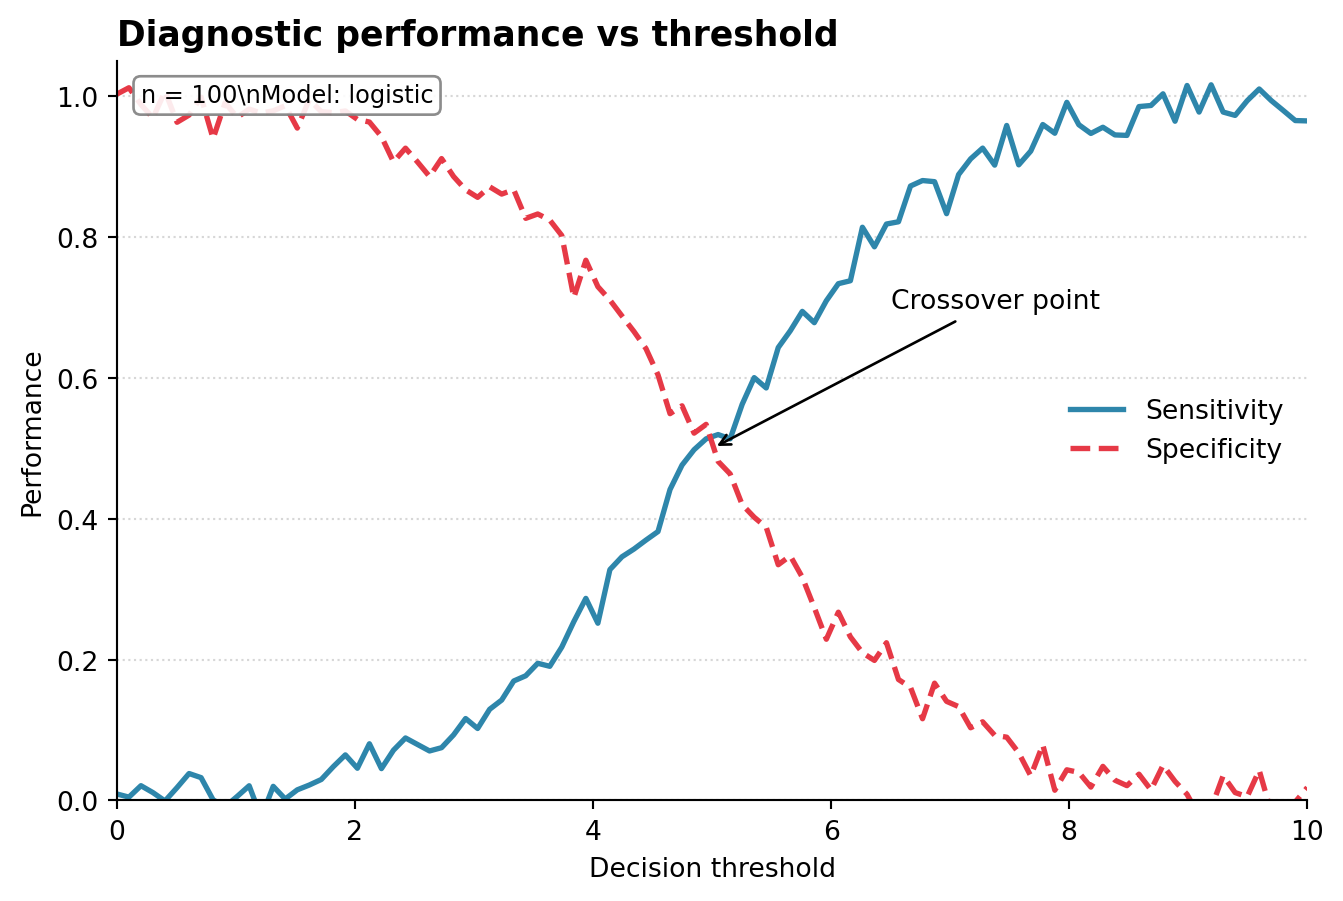

In [19]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)
x = np.linspace(0, 10, 100)
sens = 1 / (1 + np.exp(-(x - 5))) + rng.normal(0, 0.02, 100)
spec = 1 / (1 + np.exp((x - 5))) + rng.normal(0, 0.02, 100)

fig, ax = plt.subplots(figsize=(8, 5))

# Draw
ax.plot(x, sens, label="Sensitivity", linewidth=2, color="#2E86AB")
ax.plot(x, spec, label="Specificity", linewidth=2, color="#E63946", linestyle="--")

# Title and labels
ax.set_title(
    "Diagnostic performance vs threshold",
    fontsize=13,
    fontweight="bold",
    loc="left",
)
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Performance")

# Axis limits and ticks
ax.set_xlim(0, 10)
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.01, 0.2))

# Annotation pointing at the crossover
ax.annotate(
    "Crossover point",
    xy=(5, 0.5),
    xytext=(6.5, 0.7),
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=10,
)

# Stats box
ax.text(
    0.02,
    0.97,
    "n = 100\\nModel: logistic",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9),
)

# Legend
ax.legend(loc="center right", frameon=False)

# Spines and grid
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)

plt.show()

## ggplot2 → matplotlib customization cheat sheet

| ggplot2 | matplotlib |
|---|---|
| `labs(title=, x=, y=)` | `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()` |
| `xlim()`, `ylim()` | `ax.set_xlim()`, `ax.set_ylim()` |
| `scale_x_log10()` | `ax.set_xscale("log")` |
| `scale_y_continuous(labels = ...)` | `ax.yaxis.set_major_formatter(...)` |
| `theme(axis.text.x = element_text(angle = 45))` | `ax.tick_params(axis="x", rotation=45)` |
| `theme(panel.grid = ...)` | `ax.grid(True, ...)` |
| `theme(legend.position = ...)` | `ax.legend(loc=...)` |
| `theme_minimal()` style with no top/right box | `ax.spines[...].set_visible(False)` |
| `annotate("text", x=, y=, ...)` | `ax.text()` / `ax.annotate()` |
| `geom_text()` | `ax.text()` in a loop |

The pattern: ggplot2 bundles related styling under `theme()`. Matplotlib spreads it across `ax.set_*`, `ax.tick_params()`, `ax.spines`, and `ax.grid()`. Once those entry points are familiar, most customization becomes searchable and predictable.

## Exercises

### Exercise 1

Take this code and polish it:

```python
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [10, 25, 18, 30])
plt.show()
```

Add a left-aligned bold title, x and y labels, hide the top and right spines, and add a light dashed y-axis grid.

### Exercise 2

Make a bar chart of the modalities data from Module 3:

```python
modalities = ["CT", "MRI", "US", "XR"]
counts = [1240, 890, 2100, 3400]
```

Requirements:

- rotate x tick labels 30° and right-align them
- format y-axis ticks with thousands separators, such as `1,240`
- place a text label on top of each bar showing its count

Hint:

```python
for i, count in enumerate(counts):
    ax.text(i, count + 50, f"{count:,}", ha="center")
```

### Exercise 3

Make a scatter plot of 50 random `(x, y)` points where `y = x + noise`. Annotate the single highest-y point with an arrow saying `"max"`, and add a stats box in the upper-left corner of the axes using `transform=ax.transAxes`. The stats box should show the mean and standard deviation of `y`.

### Exercise 4

Reproduce the polished example above with these changes:

- log-scale the x-axis
- change the colors to a colorblind-safe pair, such as `"#0072B2"` and `"#D55E00"`
- move the legend outside the plot area on the right